<a href="https://colab.research.google.com/github/Sudecon5/Sudecon5/blob/main/MonteCarlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [38]:
#Upload file path and read csv
filepath ='/all_stocks_5yr.csv'
df = pd.read_csv(filepath, parse_dates = True, index_col='date')

#Show the data
df

,open,high,low,close,volume,Name
date,,,,,,
2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL
...,...,...,...,...,...,...
2018-02-01,76.84,78.27,76.69,77.82,2982259,ZTS
2018-02-02,77.53,78.12,76.73,76.78,2595187,ZTS
2018-02-05,76.64,76.92,73.18,73.83,2962031,ZTS


In [39]:
### Simulate future path###

#Simulation parameters
num_simulations= 10
forecast_days=365

#initialise the simulation array with all zeros
simulations = np.zeros((num_simulations,forecast_days))

#Get the close price
last_price =df['close'].iloc[-1]

#Calculate the daily returns and drop & remove any NA values
daily_returns = df['close'].pct_change().dropna()


In [40]:
#Loop through the number of simulations to forecast future cumulative returns for assets
for i in range(num_simulations):
  #Get random daily returns of size forecast days and return its cumulative return
  #Get an array of size forecast_days that contains randomly selected daily returns and calculate the cumulative return
  cumulative_returns = np.random.choice(daily_returns, size= forecast_days, replace=True).cumsum()
  #Get the simulations with the random cumulative returns
  simulations[i,:] =last_price* ( 1 +cumulative_returns)
  print(simulations)


[[ 75.15247119  71.71067349  72.87745166 ... 100.65827956 101.66706194
  100.77268833]
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]]
[[ 75.15247119  71.71067349  72.87745166 ... 100.65827956 101.66706194
  100.77268833]
 [ 73.66095771  72.74132953  73.00777975 ... 141.97894904 142.87507931
  142.55829277]
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]]
[[ 75.15247119  

In [41]:
#For simulation '3' show the first 4 random cumulative returns out of the 365 random cumulative returns starting from index 0 and not inclusing 4
print(simulations[2,0:4])

[74.8783455  75.73357644 75.41596112 75.01329757]


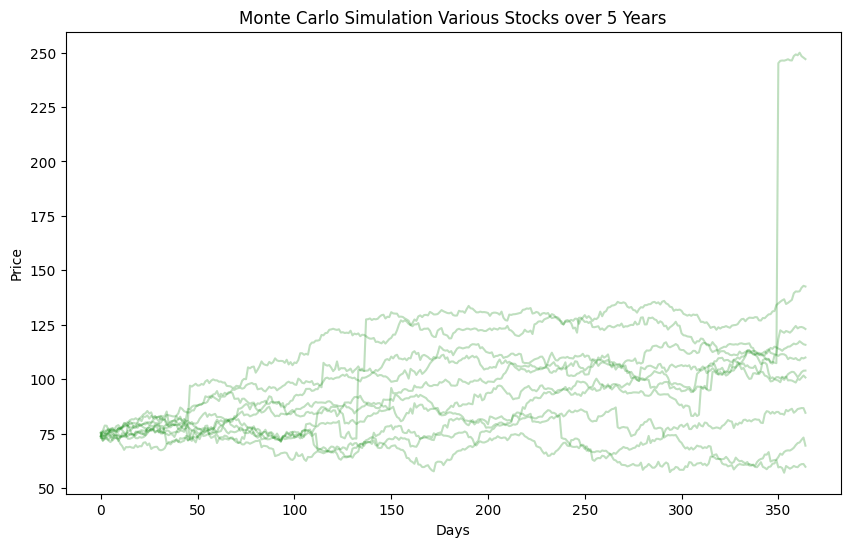

In [42]:
#Plot the result
plt.figure(figsize =(10,6))
plt.plot(simulations.T, color= 'green', alpha =0.25)
plt.title('Monte Carlo Simulation Various Stocks over 5 Years')
plt.xlabel('Days')
plt.ylabel('Price')
plt.show()


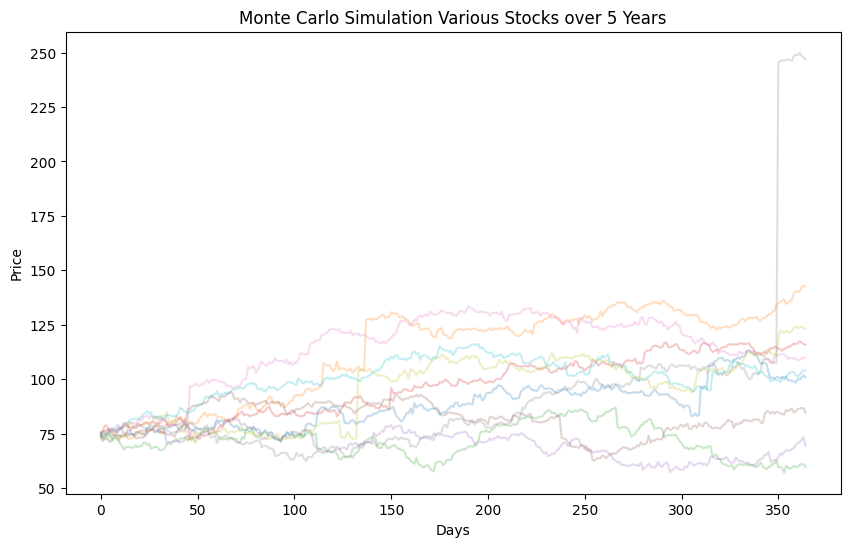

In [43]:
#Plot the result
plt.figure(figsize =(10,6))
for i in range(num_simulations):
  plt.plot(simulations[i], alpha =0.25)
plt.title('Monte Carlo Simulation Various Stocks over 5 Years')
plt.xlabel('Days')
plt.ylabel('Price')
plt.show()
